<a href="https://colab.research.google.com/github/CS171-Semester-Project/traffic-sign-detection/blob/main/traffic_sign_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

In [2]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

###**DATA PREPARATION**

In [3]:
# Download the dataset
!kaggle datasets download -d pkdarabi/cardetection

# Unzip the downloaded dataset
!unzip -q cardetection.zip -d cardetection_dataset

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:00<00:00, 124MB/s]



In [4]:
for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/train"):
    print(f"Train data path: {dirpath}")
    print(f"Train data directories length: {len(dirnames)}")
    print(f"Train data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/test"):
    print(f"Test data path: {dirpath}")
    print(f"Test data directories length: {len(dirnames)}")
    print(f"Test data filenames length: {len(filenames)}")

print()

for dirpath, dirnames, filenames in os.walk("cardetection_dataset/car/valid"):
    print(f"Validation data path: {dirpath}")
    print(f"Validation data directories length: {len(dirnames)}")
    print(f"Validation data filenames length: {len(filenames)}")

Train data path: cardetection_dataset/car/train
Train data directories length: 2
Train data filenames length: 0
Train data path: cardetection_dataset/car/train/labels
Train data directories length: 0
Train data filenames length: 3530
Train data path: cardetection_dataset/car/train/images
Train data directories length: 0
Train data filenames length: 3530

Test data path: cardetection_dataset/car/test
Test data directories length: 2
Test data filenames length: 0
Test data path: cardetection_dataset/car/test/labels
Test data directories length: 0
Test data filenames length: 638
Test data path: cardetection_dataset/car/test/images
Test data directories length: 0
Test data filenames length: 638

Validation data path: cardetection_dataset/car/valid
Validation data directories length: 2
Validation data filenames length: 0
Validation data path: cardetection_dataset/car/valid/labels
Validation data directories length: 0
Validation data filenames length: 801
Validation data path: cardetection_da

In [5]:
import yaml

yaml_path = "cardetection_dataset/car/data.yaml"

with open(yaml_path, "r") as f:
    data_info = yaml.safe_load(f)

In [6]:
# Getting all the class or label names
class_names = data_info.get('names', [])
print(f"Total Number of Classes: {len(class_names)}\n")

print("Class Names:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

Total Number of Classes: 15

Class Names:
0: Green Light
1: Red Light
2: Speed Limit 10
3: Speed Limit 100
4: Speed Limit 110
5: Speed Limit 120
6: Speed Limit 20
7: Speed Limit 30
8: Speed Limit 40
9: Speed Limit 50
10: Speed Limit 60
11: Speed Limit 70
12: Speed Limit 80
13: Speed Limit 90
14: Stop


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import glob

In [8]:
# Get all train images
view_train_img = glob.glob("cardetection_dataset/car/train/images/*.jpg")
if not view_train_img:
    view_train_img = glob.glob("cardetection_dataset/car/valid/images/*.jpg")

In [9]:
print(f"Train images length: {len(view_train_img)}")

Train images length: 3530


In [10]:
# Function to get labels for each image
def get_labels(img_path):
    label_path = img_path.replace("/images/", "/labels/").replace(".jpg", ".txt")
    found_classes = set()
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 1:
                    class_id = int(parts[0])
                    if "data_info" in globals() and "names" in data_info:
                        class_name = data_info["names"][class_id]
                    else:
                        class_name = f"Class {class_id}"
                    found_classes.add(class_name)
    if found_classes:
        return f"\nLabel: {", ".join(list(found_classes))}"

    return "\nLabel: None"

Image shape: (416, 416, 3)


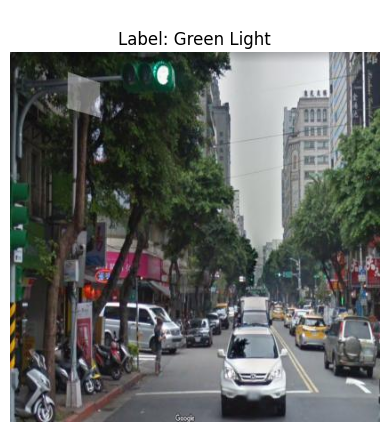

In [11]:
# Visualize one train image with a label
if view_train_img:
    train_img_path = random.choice(view_train_img)
    train_img = mpimg.imread(train_img_path)
    plt.imshow(train_img)
    title = get_labels(train_img_path)
    plt.title(title)
    plt.axis("off")
    print(f"Image shape: {train_img.shape}")
    plt.show()
else:
    print("No train images found")

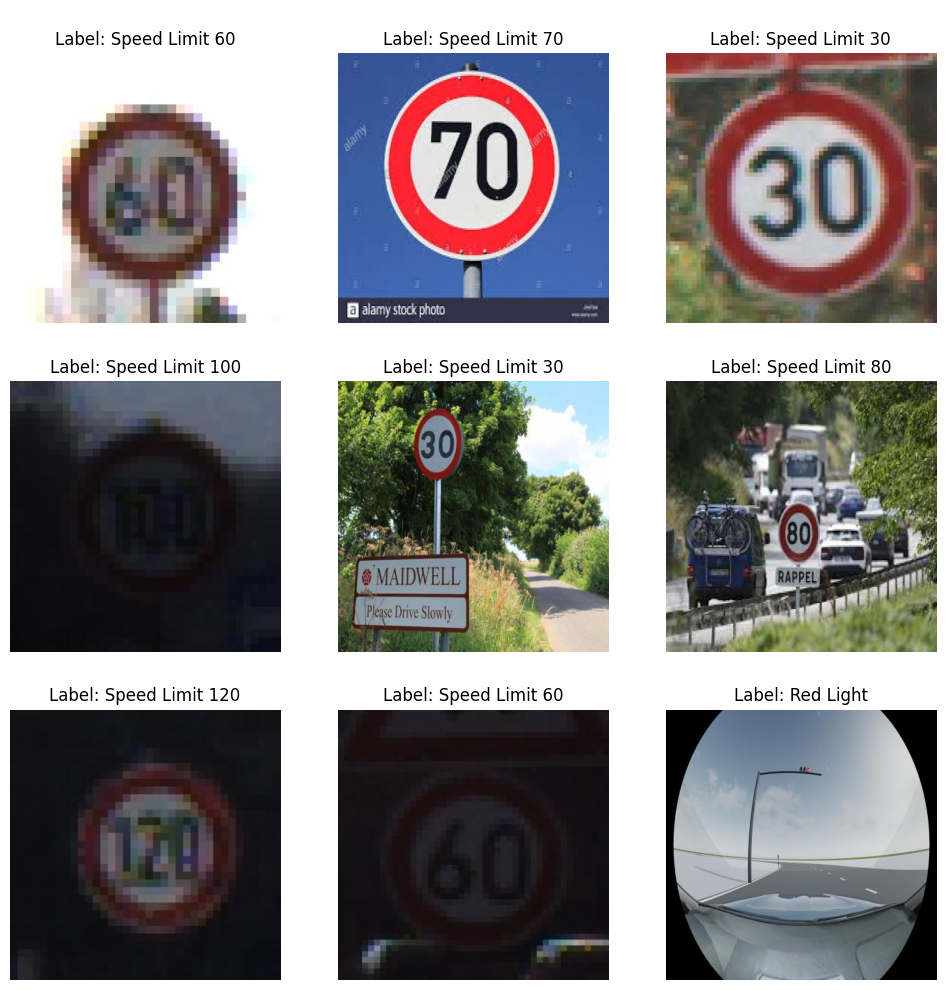

In [12]:
# Visualize multiple train images with labels
samples = random.sample(view_train_img, min(9, len(view_train_img)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, img_path in enumerate(samples):
    ax =axes[i]
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    title = get_labels(img_path)
    ax.set_title(title)

plt.tight_layout()
plt.show()

###**DATA PREPROCESSING**

In [13]:
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [14]:
class TrafficSignDataset(Dataset):
    def __init__(self, img_dir, label_dir, S=7, B=2, C=15, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C
        self.images = [
            f for f in os.listdir(img_dir)
            if f.endswith(('.jpg', '.png', '.jpeg'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_file = self.images[index]
        img_path = os.path.join(self.img_dir, img_file)

        # Determine corresponding label file path
        label_file = img_file.rsplit('.', 1)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)

        # Parse bounding boxes
        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    data = line.strip().split()
                    if data:
                        class_label = int(data[0])
                        x = float(data[1])
                        y = float(data[2])
                        width = float(data[3])
                        height = float(data[4])
                        boxes.append([class_label, x, y, width, height])

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Apply transformations.
        # Note: Since YOLO coordinates are normalized, standard resizing
        # preserves spatial accuracy without altering the bounding box values.
        if self.transform:
            image = self.transform(image)

        # Initialize target tensor
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        for box in boxes:
            class_label, x, y, width, height = box

            # Grid Assignment
            i, j = int(self.S * y), int(self.S * x)

            # Coordinate Conversion
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # Tensor Population
            if label_matrix[i, j, self.C] == 0:
                # Set objectness score to 1
                label_matrix[i, j, self.C] = 1

                # Assign relative box coordinates
                box_coordinates = torch.tensor(
                    [x_cell, y_cell, width_cell, height_cell]
                )
                label_matrix[i, j, self.C + 1: self.C + 5] = box_coordinates

                # Apply one-hot encoding for the class
                label_matrix[i, j, class_label] = 1

        return image, label_matrix

In [15]:
# Define execution parameters
GRID_SIZE = 7
BBOXES = 2
CLASSES = 15
BATCH_SIZE = 16
NUM_WORKERS = 2

# Define transformations
transform_pipeline = transforms.Compose([
    transforms.Resize((416, 416)),
    transforms.ToTensor(),
])

# Define directory paths
train_img_dir = 'cardetection_dataset/car/train/images'
train_label_dir = 'cardetection_dataset/car/train/labels'
val_img_dir = 'cardetection_dataset/car/valid/images'
val_label_dir = 'cardetection_dataset/car/valid/labels'
test_img_dir = 'cardetection_dataset/car/test/images'
test_label_dir = 'cardetection_dataset/car/test/labels'

# Instantiate datasets
train_dataset = TrafficSignDataset(
    img_dir=train_img_dir,
    label_dir=train_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

val_dataset = TrafficSignDataset(
    img_dir=val_img_dir,
    label_dir=val_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

test_dataset = TrafficSignDataset(
    img_dir=test_img_dir,
    label_dir=test_label_dir,
    S=GRID_SIZE, B=BBOXES, C=CLASSES,
    transform=transform_pipeline
)

# Initialize DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=False,
    drop_last=False
)

###**MODEL BUILDING**

In [16]:
import torch.nn as nn

In [17]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1) # To prevent vanishing gradients by multiplying 0.1 if gradients are negative, instead of regular ReLU

    def forward(self, x):
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class TrafficSignDetector(nn.Module):
    def __init__(self, in_channels=3):
        super(TrafficSignDetector, self).__init__()
        self.S = 7
        self.B = 2
        self.C = 15

        # Define the convolutional architecture explicitly without config variables
        self.features = nn.Sequential(
            CNNBlock(in_channels, 64, kernel_size=7, stride=2, padding=3),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(64, 192, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(192, 128, kernel_size=1),
            CNNBlock(128, 256, kernel_size=3, padding=1),
            CNNBlock(256, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 256, kernel_size=1),
            CNNBlock(256, 512, kernel_size=3, padding=1),
            CNNBlock(512, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            nn.MaxPool2d(kernel_size=2, stride=2),

            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 512, kernel_size=1),
            CNNBlock(512, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, stride=2, padding=1),

            CNNBlock(1024, 1024, kernel_size=3, padding=1),
            CNNBlock(1024, 1024, kernel_size=3, padding=1),

            # Ensures output grid is strictly 7x7 even if input res is 416x416
            nn.AdaptiveAvgPool2d((self.S, self.S))
        )

        # Define the fully connected layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * self.S * self.S, 4096),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, self.S * self.S * (self.C + self.B * 5))
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)

        # Reshape to match teammate's DataLoader target tensor format
        # Targets format: (Batch, S, S, C + 5 * B)
        x = x.view(-1, self.S, self.S, self.C + self.B * 5)
        return x

# Instantiate the model
num_classes = len(class_names)

In [18]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [19]:
model = TrafficSignDetector(in_channels=3)

In [20]:
!pip install torchinfo

In [21]:
# Get model summary
import torchinfo

torchinfo.summary(model=model)

Layer (type:depth-idx)                   Param #
TrafficSignDetector                      --
├─Sequential: 1-1                        --
│    └─CNNBlock: 2-1                     --
│    │    └─Conv2d: 3-1                  9,408
│    │    └─BatchNorm2d: 3-2             128
│    │    └─LeakyReLU: 3-3               --
│    └─MaxPool2d: 2-2                    --
│    └─CNNBlock: 2-3                     --
│    │    └─Conv2d: 3-4                  110,592
│    │    └─BatchNorm2d: 3-5             384
│    │    └─LeakyReLU: 3-6               --
│    └─MaxPool2d: 2-4                    --
│    └─CNNBlock: 2-5                     --
│    │    └─Conv2d: 3-7                  24,576
│    │    └─BatchNorm2d: 3-8             256
│    │    └─LeakyReLU: 3-9               --
│    └─CNNBlock: 2-6                     --
│    │    └─Conv2d: 3-10                 294,912
│    │    └─BatchNorm2d: 3-11            512
│    │    └─LeakyReLU: 3-12              --
│    └─CNNBlock: 2-7                     --
│    │

###**MODEL TRAINING**

In [22]:
import torch.optim as optim
from torchvision.ops import box_iou, box_convert

In [23]:
class CustomLoss(nn.Module):
    def __init__(self, S=7, B=2, C=15):
        super(CustomLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)
        target = target.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # Extract bounding boxes for both predictions
        box1_preds = predictions[..., self.C+1 : self.C+5]
        box2_preds = predictions[..., self.C+6 : self.C+10]

        target_boxes = target[..., self.C+1 : self.C+5]

        box1_preds_xyxy = box_convert(box1_preds.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')
        box2_preds_xyxy = box_convert(box2_preds.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')
        target_boxes_xyxy = box_convert(target_boxes.reshape(-1, 4), in_fmt='cxcywh', out_fmt='xyxy')

        iou_b1 = box_iou(box1_preds_xyxy, target_boxes_xyxy).diag().reshape(-1, self.S, self.S, 1)
        iou_b2 = box_iou(box2_preds_xyxy, target_boxes_xyxy).diag().reshape(-1, self.S, self.S, 1)

        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)
        iou_maxes, bestbox = torch.max(ious, dim=0)

        exists_box = target[..., self.C].unsqueeze(3)

        # For box coordinates
        box_predictions = exists_box * (
            (
                bestbox * predictions[..., self.C+6 : self.C+10]
                + (1 - bestbox) * predictions[..., self.C+1 : self.C+5]
            )
        )
        box_targets = exists_box * target_boxes

        # We add 1e-6 to prevent gradient explosion at derivative of sqrt(0)
        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2)
        )

        # Object detected loss
        pred_box = (
            bestbox * predictions[..., self.C+5 : self.C+6]
            + (1 - bestbox) * predictions[..., self.C : self.C+1]
        )
        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., self.C : self.C+1])
        )

        # No object detected loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C : self.C+1], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )
        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C+5 : self.C+6], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., self.C : self.C+1], start_dim=1)
        )

        # Classification loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :self.C], end_dim=-2),
            torch.flatten(exists_box * target[..., :self.C], end_dim=-2)
        )

        # Total loss
        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss / predictions.shape[0]

custom_loss_module = CustomLoss(S=7, B=2, C=15)

def custom_loss(predictions, targets):
    return custom_loss_module(predictions, targets)

# Standard optimizer
optimizer = optim.Adam(params=model.parameters(), lr=0.001)

In [24]:
from tqdm import tqdm

In [25]:
learning_rate = 2e-5
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0)

model.to(device)

def train_fn(train_loader, model, optimizer, loss_fn):
    # tqdm provides a progress bar just like in the remote repo
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)

        out = model(x)
        loss = loss_fn(out, y)

        mean_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # update progress bar
        loop.set_postfix(loss=loss.item())

    return sum(mean_loss) / len(mean_loss)

epochs = 5
epoch_count = []
loss_values = []

print(f"Starting training on {device}...")
for epoch in range(epochs):
    print(f"\nEpoch: {epoch+1}/{epochs}")
    model.train()

    # Train for one epoch using our custom YOLO loss
    avg_loss = train_fn(train_loader, model, optimizer, custom_loss)

    epoch_count.append(epoch + 1)
    loss_values.append(avg_loss)

    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

Starting training on cuda...

Epoch: 1/5


100%|██████████| 220/220 [01:37<00:00,  2.26it/s, loss=7.19]


Epoch 1 Average Loss: 8.7013

Epoch: 2/5


100%|██████████| 220/220 [01:35<00:00,  2.30it/s, loss=5.78]


Epoch 2 Average Loss: 5.0812

Epoch: 3/5


...

Epoch 3 Average Loss: 4.1991

Epoch: 4/5


100%|██████████| 220/220 [01:35<00:00,  2.30it/s, loss=3.07]


Epoch 4 Average Loss: 3.7733

Epoch: 5/5


100%|██████████| 220/220 [01:36<00:00,  2.29it/s, loss=3.71]

Epoch 5 Average Loss: 3.4048


###**MODEL TESTING**

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [27]:
# Gather predicted and actual values
def get_predictions(model, dataloader, device, conf_threshold=0.2):
    model.eval()
    all_preds = []
    all_targets = []

    S = 7
    B = 2
    C = 15

    with torch.inference_mode():
        for images, targets in dataloader:
            images = images.to(device)
            targets = targets.to(device)

            logits = model(images)
            batch_size = logits.shape[0]

            # Reshape predictions and targets
            predictions = logits.reshape(-1, S, S, C + B * 5)
            targets = targets.reshape(-1, S, S, C + B * 5)

            for b in range(batch_size):
                pred = predictions[b]

                # Get classes, confidences, and boxes
                pred_classes = torch.argmax(pred[..., :C], dim=-1)

                # Extract boxes and confidences
                conf1 = pred[..., C:C+1]
                box1 = pred[..., C+1:C+5]
                conf2 = pred[..., C+5:C+6]
                box2 = pred[..., C+6:C+10]

                # Choose the box with the highest confidence for each grid cell
                conf_mask = conf1 > conf2
                best_conf = torch.where(conf_mask, conf1, conf2).squeeze(-1)
                best_box = torch.where(conf_mask.expand_as(box1), box1, box2)

                # Filter by confidence threshold
                mask = best_conf > conf_threshold

                filtered_boxes = best_box[mask]
                filtered_scores = best_conf[mask]
                filtered_classes = pred_classes[mask]

                if filtered_boxes.shape[0] > 0:
                    pred_boxes_xyxy = box_convert(filtered_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    pred_boxes_xyxy = torch.empty((0, 4), device=device)

                all_preds.append({
                    'boxes': pred_boxes_xyxy,
                    'scores': filtered_scores,
                    'labels': filtered_classes
                })

                target = targets[b]

                target_conf = target[..., C]
                target_classes = torch.argmax(target[..., :C], dim=-1)
                target_boxes = target[..., C+1:C+5]

                obj_mask = target_conf == 1

                t_boxes = target_boxes[obj_mask]
                t_labels = target_classes[obj_mask]

                if t_boxes.shape[0] > 0:
                    target_boxes_xyxy = box_convert(t_boxes, in_fmt='cxcywh', out_fmt='xyxy')
                else:
                    target_boxes_xyxy = torch.empty((0, 4), device=device)

                all_targets.append({
                    'boxes': target_boxes_xyxy,
                    'labels': t_labels
                })

    return all_preds, all_targets

In [28]:
train_labels, train_preds = get_predictions(model, train_loader)
test_labels, test_preds = get_predictions(model, test_loader)

TypeError: get_predictions() missing 1 required positional argument: 'device'

###**MODEL EVALUATION**

In [29]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.0 MB/s eta 0:00:00


In [30]:
from sklearn.metrics import f1_score
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [31]:
def evaluate_model(model, dataloader, device):
    print("Evaluating model...")
    map_metric = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

    # Get predictions and targets in the format expected by torchmetrics
    preds, targets = get_predictions(model, dataloader, device)

    map_metric.update(preds, targets)
    map_results = map_metric.compute()

    print(f"mAP (IoU=0.50:0.95): {map_results['map']:.4f}")
    print(f"mAP (IoU=0.50): {map_results['map_50']:.4f}")
    print(f"mAP (IoU=0.75): {map_results['map_75']:.4f}")

    return map_results['map']

test_map = evaluate_model(model, test_loader, device)

Evaluating model...
mAP (IoU=0.50:0.95): 0.0936
mAP (IoU=0.50): 0.1466
mAP (IoU=0.75): 0.1083


###**VISUALIZATION OF RESULTS**

In [32]:
from sklearn.metrics import confusion_matrix

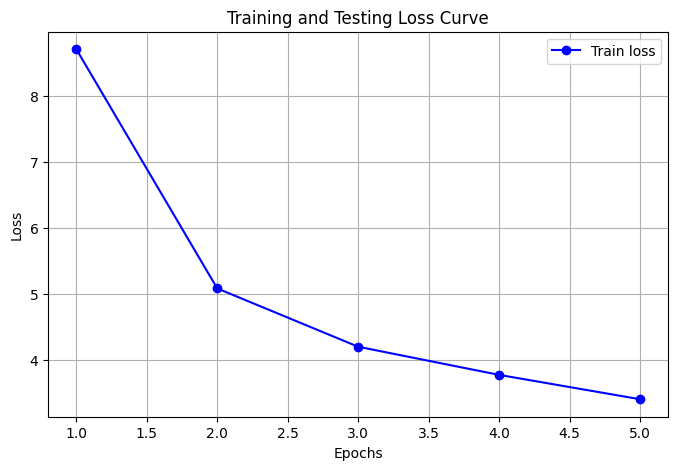

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(epoch_count, loss_values, label="Train loss", color="blue", marker="o")
#plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Testing Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_701/593667797.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(15)), y=target_counts, ax=ax[0], palette='Blues')
/tmp/ipykernel_701/593667797.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(15)), y=pred_counts, ax=ax[1], palette='Oranges')


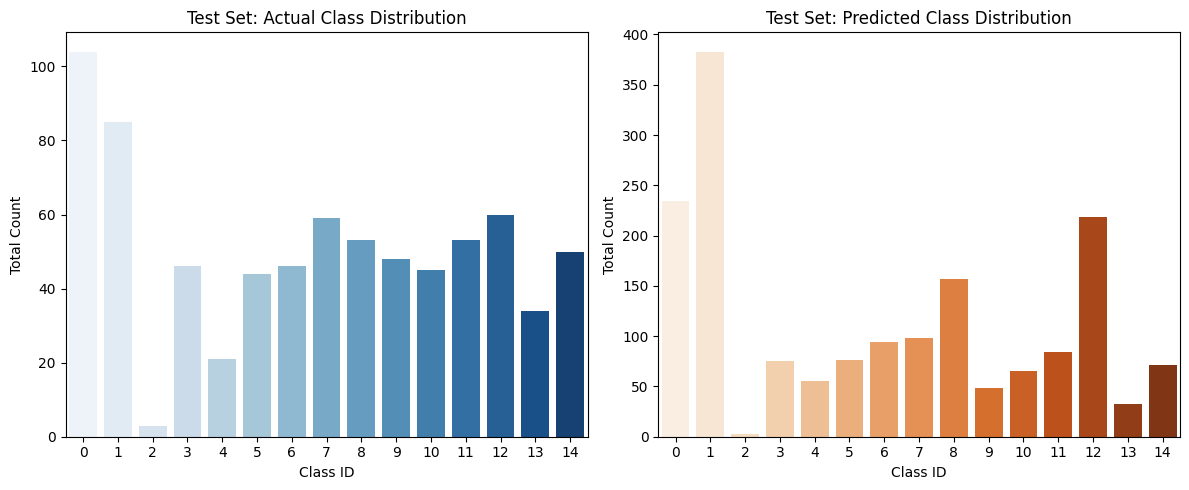

In [35]:
def get_class_counts(target_list, num_classes=15):
    counts = np.zeros(num_classes)
    for t in target_list:
        for label in t['labels']:
            counts[label.item()] += 1
    return counts

preds, targets = get_predictions(model, test_loader, device)

pred_counts = get_class_counts(preds)
target_counts = get_class_counts(targets)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=list(range(15)), y=target_counts, ax=ax[0], palette='Blues')
ax[0].set_title('Test Set: Actual Class Distribution')
ax[0].set_xlabel('Class ID')
ax[0].set_ylabel('Total Count')

sns.barplot(x=list(range(15)), y=pred_counts, ax=ax[1], palette='Oranges')
ax[1].set_title('Test Set: Predicted Class Distribution')
ax[1].set_xlabel('Class ID')
ax[1].set_ylabel('Total Count')

plt.tight_layout()
plt.show()